In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/supp-figures"
st.utils.setup_plotting(figure_dir, display_dpi=200)

import pandas as pd
import scanpy as sc

## Load data

In [2]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.2-kidney_tcr_clonal_clusters_peri_glom_annot.h5ad"
adata = sc.read_h5ad(path)

# remove control samples
adata = adata[adata.obs["condition"] == "ANCA"].copy()
sample_mapping = {k: f"S{i}" for i, k in enumerate(adata.obs["sample"].unique())}
adata.obs["sample_short"] = adata.obs["sample"].map(sample_mapping)
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [3]:
adata.obs.columns

Index(['sample', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'control_codeword_counts',
       'unassigned_codeword_counts', 'deprecated_codeword_counts',
       'total_counts', 'cell_area', 'nucleus_area', 'slide',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts',
       'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob',
       'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B',
       'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST',
       'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC',
       'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P',
       'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden',
       'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density',
   

In [4]:
adata.obs["avbv_cluster_filtered"]

aaaafjcl-1output-XETG00088__0029040__Region_4__20240719__095642    NaN
aaaaifkm-1output-XETG00088__0029040__Region_4__20240719__095642    NaN
aaabfnjj-1output-XETG00088__0029040__Region_4__20240719__095642    NaN
aaacfpcn-1output-XETG00088__0029040__Region_4__20240719__095642    NaN
aaadlcmd-1output-XETG00088__0029040__Region_4__20240719__095642    NaN
                                                                  ... 
ojhmonnc-1output-XETG00088__0029040__Region_5__20240719__095642    NaN
ojhngikd-1output-XETG00088__0029040__Region_5__20240719__095642    NaN
ojibodbj-1output-XETG00088__0029040__Region_5__20240719__095642    NaN
ojicdocl-1output-XETG00088__0029040__Region_5__20240719__095642    NaN
ojidgecb-1output-XETG00088__0029040__Region_5__20240719__095642    NaN
Name: avbv_cluster_filtered, Length: 389390, dtype: category
Categories (145, object): ['TRAV1-1+TRBV5-6_C0', 'TRAV1-2+TRBV4_C5', 'TRAV1-2+TRBV6_C7', 'TRAV1-2+TRBV7-2_3_C9', ..., 'TRAV39+TRBV4_C72', 'TRAV39+TRBV4_C73', 

In [5]:
# get cd8 dominant ccs
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()
ad_cluster = adata[adata.obs["avbv_cluster"].notna()].copy()
ct_key = "cell_type_l1.1"
df = (
    ad_cluster.obs.groupby("avbv_cluster", observed=True)[ct_key]
    .value_counts(normalize=True)
    .unstack()
)
cd8_dominant_ccs = df.index[df["CD8+"] >= 0.5].tolist()
adata.obs["cd8_dominant_ccs"] = adata.obs["avbv_cluster"].astype(str)
adata.obs.loc[
    ~adata.obs["cd8_dominant_ccs"].isin(cd8_dominant_ccs), "cd8_dominant_ccs"
] = pd.NA
print(f"Number of CD8+ ccs: {len(cd8_dominant_ccs)}")

Number of CD8+ ccs: 100


## Check localization of CD8+ clusters in periglomerular and tubulointerstitial regions

/tmp/ipykernel_103125/3168974938.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


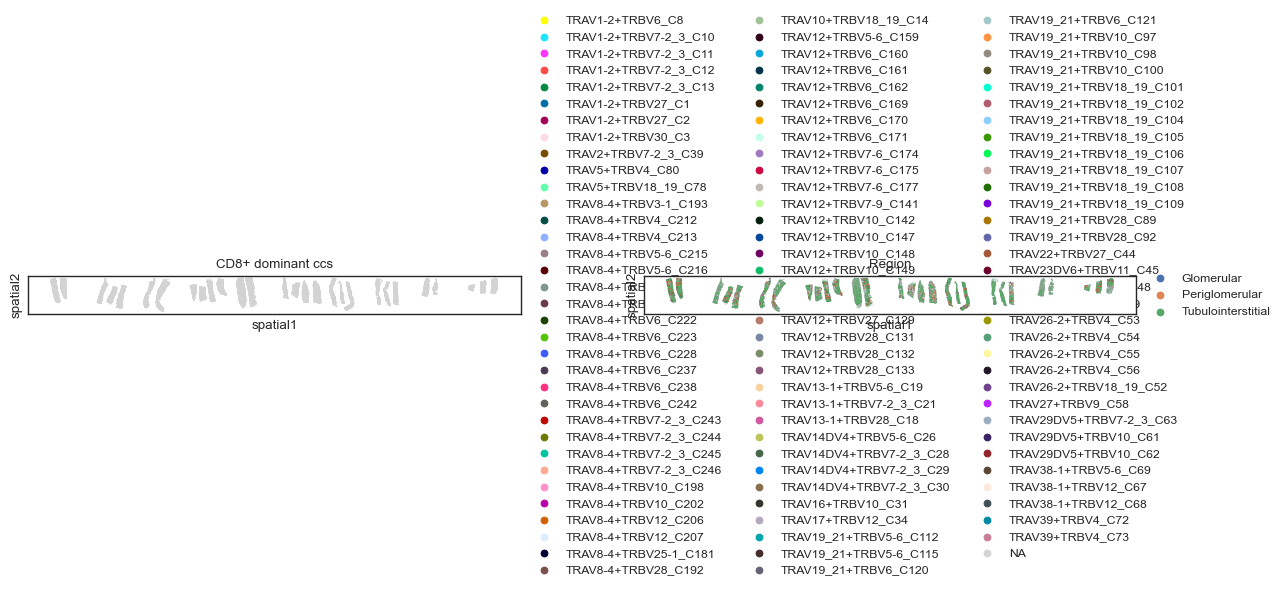

In [6]:
adata.obs["in_tubuloint"] = (~adata.obs["in_glom"]) & (~adata.obs["in_peri_glom"])
adata.obs["region"] = "Tubulointerstitial"
adata.obs.loc[adata.obs["in_glom"], "region"] = "Glomerular"
adata.obs.loc[adata.obs["in_peri_glom"], "region"] = "Periglomerular"

sc.pl.spatial(
    adata,
    color=["cd8_dominant_ccs", "region"],
    title=["CD8+ dominant ccs", "Region"],
    spot_size=10,
)

## Compare CD8+ clonal clusters vs CD8+ T cells per region


Global test (chi2) for all samples


(<Figure size 400x1000 with 1 Axes>,
 array([<Axes: title={'center': 'CD8+ clonal clusters vs CD8+ T cells'}, xlabel='Group', ylabel='Proportion'>],
       dtype=object))

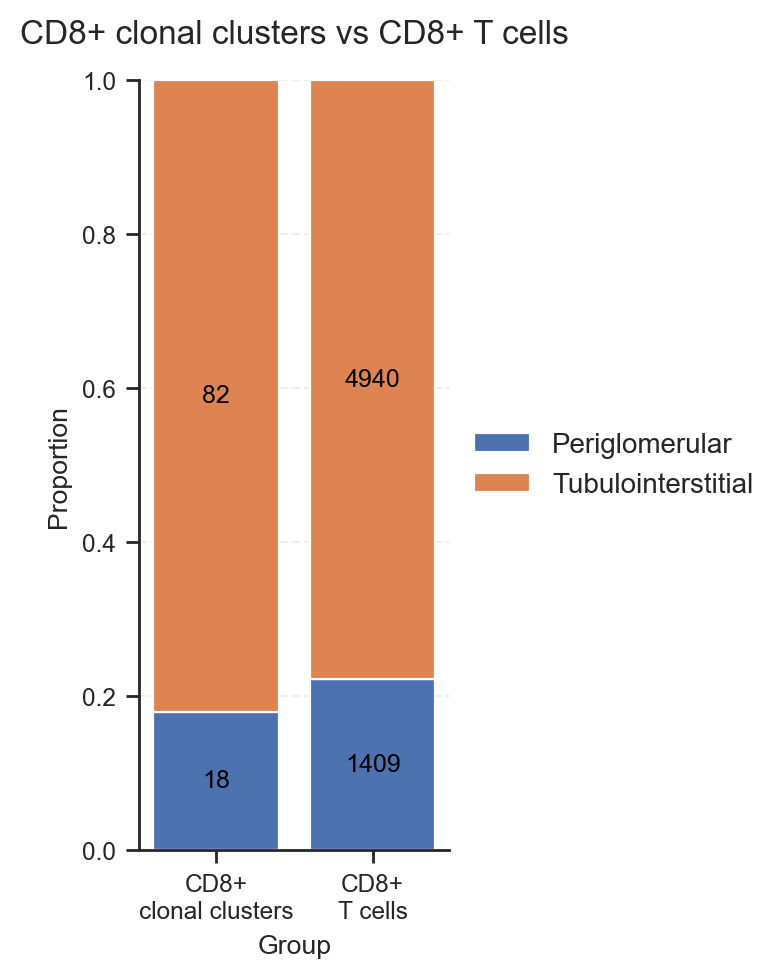

In [11]:
from spatial_tcr.plotting import plot_cd8_clonal_clusters_vs_cells_stacked

plot_cd8_clonal_clusters_vs_cells_stacked(
    adata,
    region_col="region",
    cc_col="cd8_dominant_ccs",
    cell_type_col="cell_type_l1.1",
    cell_type="CD8+",
    exclude_regions=["Glomerular"],
    figsize=(2, 5),
    show_absolute_counts=True,
    test_method="chi2",
    annotate_significance=False,
)

Global test (fisher) for S0
Global test (fisher) for S9
Global test (fisher) for S4
Global test (fisher) for S3
Global test (fisher) for S1
Global test (fisher) for S5
Global test (fisher) for S2
Global test (fisher) for S8
Global test (fisher) for S7
Global test (fisher) for S6


(<Figure size 1875x1600 with 10 Axes>,
 array([<Axes: title={'center': 'S0'}, xlabel='Group', ylabel='Proportion'>,
        <Axes: title={'center': 'S9'}, xlabel='Group'>,
        <Axes: title={'center': 'S4'}, xlabel='Group'>,
        <Axes: title={'center': 'S3'}, xlabel='Group'>,
        <Axes: title={'center': 'S1'}, xlabel='Group'>,
        <Axes: title={'center': 'S5'}, xlabel='Group', ylabel='Proportion'>,
        <Axes: title={'center': 'S2'}, xlabel='Group'>,
        <Axes: title={'center': 'S8'}, xlabel='Group'>,
        <Axes: title={'center': 'S7'}, xlabel='Group'>,
        <Axes: title={'center': 'S6'}, xlabel='Group'>], dtype=object))

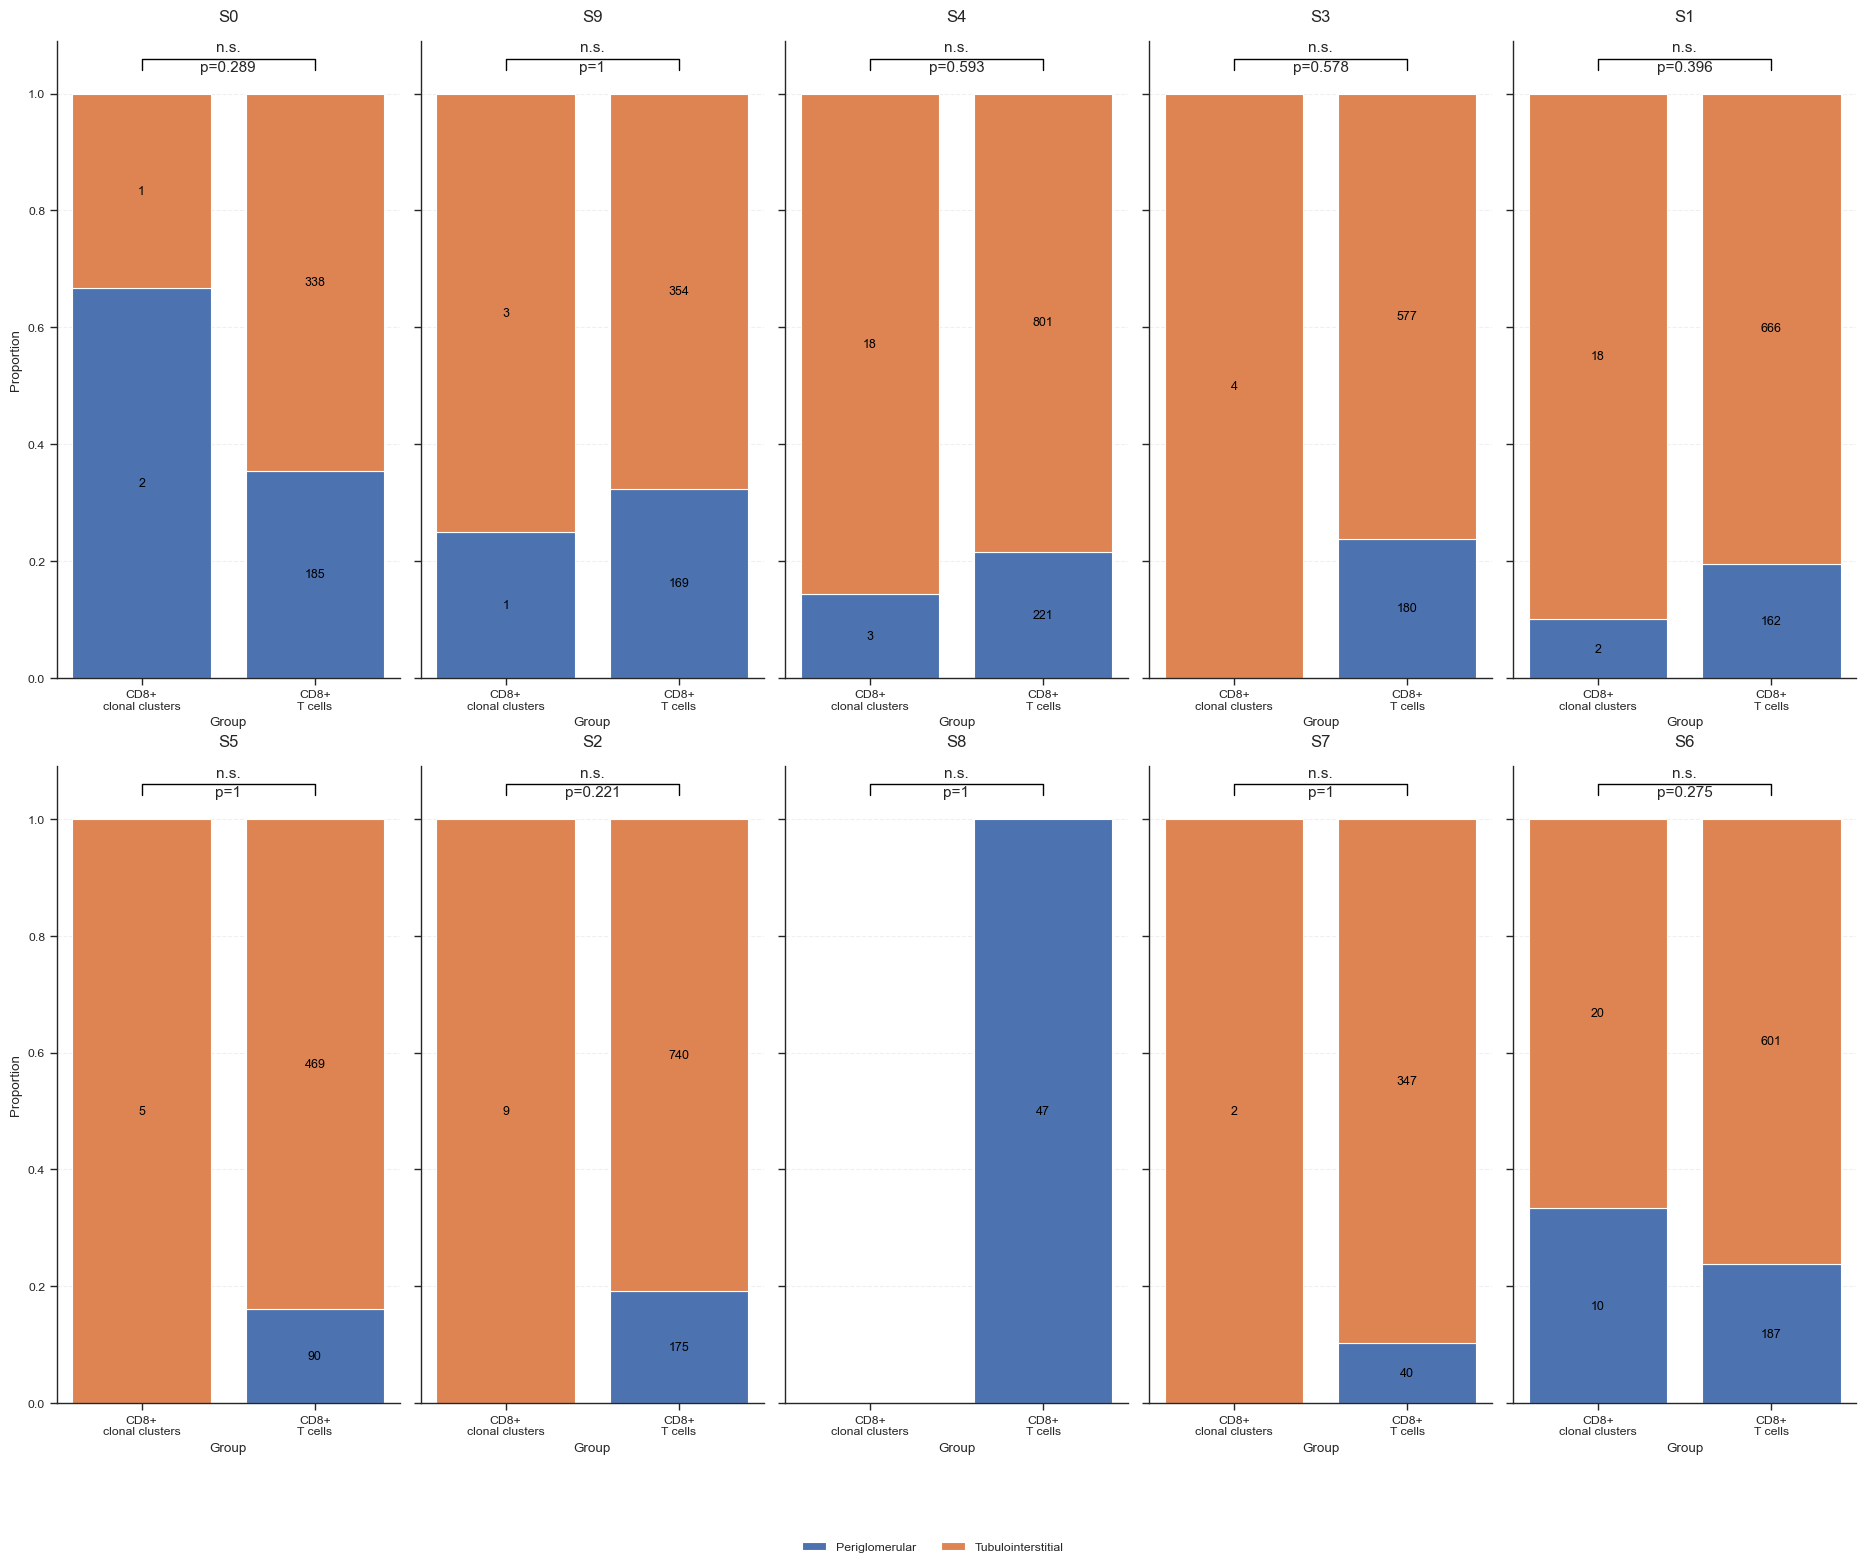

In [41]:
ncols = 5
plot_cd8_clonal_clusters_vs_cells_stacked(
    adata,
    region_col="region",
    cc_col="cd8_dominant_ccs",
    cell_type_col="cell_type_l1.1",
    cell_type="CD8+",
    exclude_regions=["Glomerular"],
    figsize=(ncols * 0.75, 8),
    ncols=ncols,
    sample_col="sample_short",
    show_raw_pvalues=True,
    show_absolute_counts=True,
    test_method="fisher",
)

Global test p-value: 0.3621554778325785


/bonn-epyc/projects/dschaub/analysis-projects/xenium-tcr/src/spatial_tcr/plotting.py:849: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cc_region_counts.groupby(cc_col)["count"].idxmax()


<Axes: title={'center': 'CD8+ clonal clusters vs CD8+ T cells per region'}, ylabel='Fraction'>

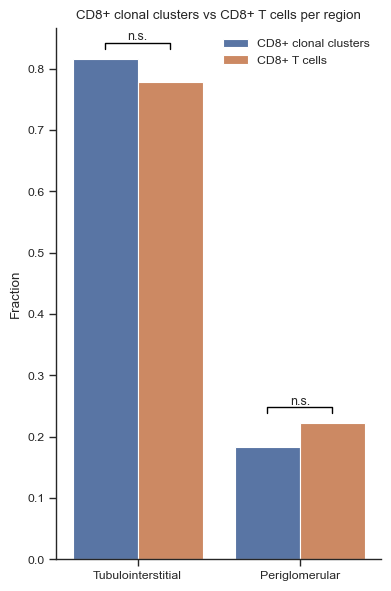

In [18]:
from spatial_tcr.plotting import plot_cd8_clonal_clusters_vs_cells_per_region

plot_cd8_clonal_clusters_vs_cells_per_region(
    adata,
    normalize=True,
    title="CD8+ clonal clusters vs CD8+ T cells per region",
    exclude_regions=["Glomerular"],
    figsize=(4, 6),
)